# 📈 Predictive Analytics Using Historical Data

## Sales Forecasting Using Historical Data

### Thiranex Data Analytics Internship — Task 3

**Objective:**  
Build a predictive analytics model using historical sales data to identify trends,
evaluate prediction accuracy, and forecast future sales.

### Project Goals

- Clean and preprocess historical sales data
- Perform exploratory data analysis
- Analyze historical sales trends
- Build a regression-based predictive model
- Evaluate model performance
- Visualize actual vs predicted sales
- Forecast future sales
- Present insights through an interactive dashboard

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Streamlit

## 1. Import Required Libraries

The following Python libraries are used for data manipulation,
visualization, machine learning, and model evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

## 2. Load the Historical Sales Dataset

The dataset contains monthly sales records from 2022 to 2025.

The `Date` column represents the sales month, while the `Sales` column
represents the total sales for that month.

In [ ]:
df = pd.read_csv("../data/historical_sales.csv")

df.head()

,Date,Sales
0,2022-01-01,12000
1,2022-02-01,12500
2,2022-03-01,13200
3,2022-04-01,12800
4,2022-05-01,14000


## 3. Understand the Dataset

Before performing analysis, we inspect the structure, dimensions,
data types, and basic statistics of the dataset.

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Records:")
display(df.head())

Dataset Shape: (48, 2)

Column Names:
['Date', 'Sales']

Data Types:
Date       str
Sales    int64
dtype: object

First 5 Records:


,Date,Sales
0,2022-01-01,12000
1,2022-02-01,12500
2,2022-03-01,13200
3,2022-04-01,12800
4,2022-05-01,14000


## 4. Check for Missing Values

Missing values can affect the accuracy of predictive models.
Therefore, we check every column for missing observations.

In [3]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Date            0
Sales           0
Month_Number    0
dtype: int64


## 5. Data Preprocessing

The `Date` column is converted from text format into a datetime format.
The dataset is then sorted chronologically to maintain the correct
time order required for historical trend analysis.

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Sales
0,2022-01-01,12000
1,2022-02-01,12500
2,2022-03-01,13200
3,2022-04-01,12800
4,2022-05-01,14000


## 6. Descriptive Statistics

Descriptive statistics help us understand the distribution of historical
sales values, including the average, minimum, maximum, and variation.

In [ ]:
df.describe()

,Date,Sales
count,48,48.000000
mean,2023-12-16 11:00:00,21452.083333
min,2022-01-01 00:00:00,12000.000000
25%,2022-12-24 06:00:00,16425.000000
50%,2023-12-16 12:00:00,20650.000000
75%,2024-12-08 18:00:00,25625.000000
max,2025-12-01 00:00:00,37000.000000
std,NaN,6074.606706


## 7. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand historical
sales patterns and identify trends over time.

The first visualization shows how sales have changed month by month.

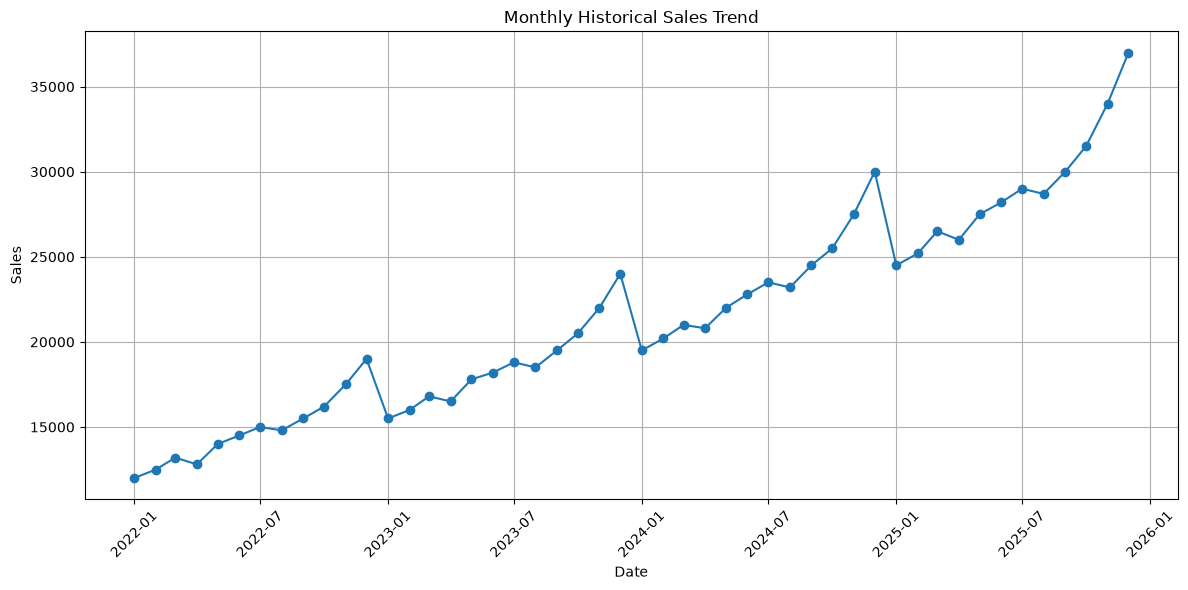

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Sales"], marker="o")

plt.title("Monthly Historical Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The sales trend shows an overall upward movement over the historical
period. Although some months experience small fluctuations, the general
pattern indicates increasing sales over time.

## 8. Yearly Sales Analysis

To understand long-term growth, the monthly sales values are aggregated
by year.

In [ ]:
df["Year"] = df["Date"].dt.year

yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()

yearly_sales

,Year,Sales
0,2022,177000
1,2023,224100
2,2024,280500
3,2025,348100


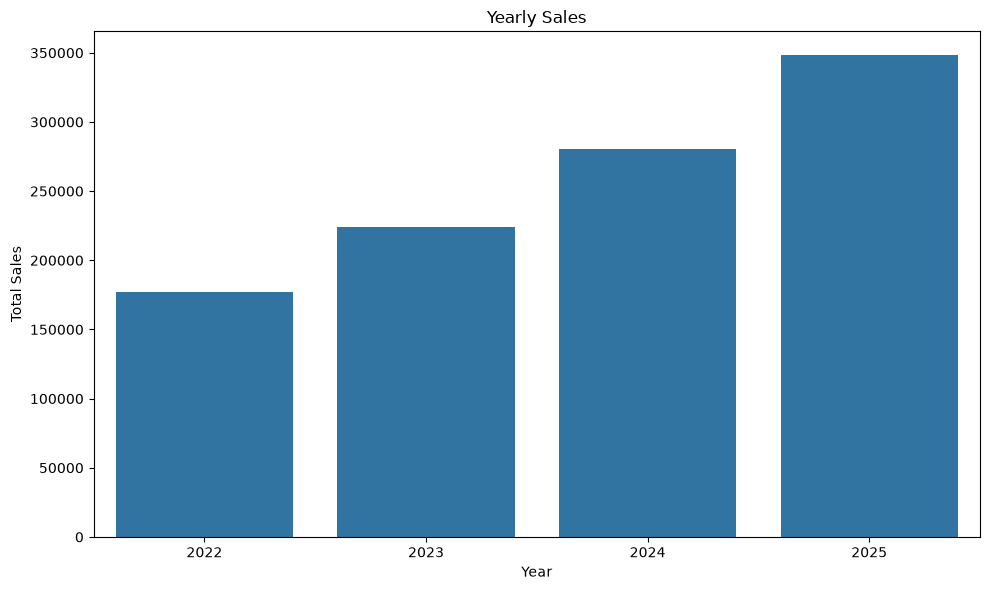

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(data=yearly_sales, x="Year", y="Sales")

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation

The yearly analysis indicates that total sales have increased across
the observed years, suggesting a positive long-term sales trend.

## 9. Feature Engineering

Machine learning models require numerical input features.

A time-based feature called `Month_Number` is created from the date.
The sequential time index allows the regression model to learn the
relationship between time and sales.


In [ ]:
df["Month_Number"] = np.arange(1, len(df) + 1)

df.head()

,Date,Sales,Year,Month_Number
0,2022-01-01,12000,2022,1
1,2022-02-01,12500,2022,2
2,2022-03-01,13200,2022,3
3,2022-04-01,12800,2022,4
4,2022-05-01,14000,2022,5


## 10. Define Features and Target

The `Month_Number` is used as the independent variable (feature),
while `Sales` is the dependent variable (target).

The model will learn historical sales patterns and use them to
predict sales values.

In [2]:
X = df[["Month_Number"]]
y = df["Sales"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (48, 1)
Target Shape: (48,)


## 11. Split the Historical Data

Because this is time-based data, the dataset is divided chronologically.

The first 80% of observations are used for training and the remaining
20% are used for testing.

This approach prevents future observations from being used to train
the model.

In [4]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 38
Testing Records: 10


## 12. Train the Linear Regression Model

Linear Regression is used to model the relationship between time
and historical sales.

The trained model will be used to predict sales for the testing
period and future months.

In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## 13. Generate Predictions

The trained Linear Regression model is used to predict sales for
the testing period.

These predictions will later be compared with the actual sales
values to evaluate the model's performance.

In [6]:
y_pred = model.predict(X_test)

prediction_results = pd.DataFrame({
    "Date": df.loc[X_test.index, "Date"],
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

prediction_results

,Date,Actual Sales,Predicted Sales
38,2025-03-01,26500,26705.689900
39,2025-04-01,26000,27088.302878
40,2025-05-01,27500,27470.915855
41,2025-06-01,28200,27853.528832
42,2025-07-01,29000,28236.141810
43,2025-08-01,28700,28618.754787
44,2025-09-01,30000,29001.367765
45,2025-10-01,31500,29383.980742
46,2025-11-01,34000,29766.593719
47,2025-12-01,37000,30149.206697


## 14. Evaluate Model Accuracy

The model is evaluated using three important metrics:

- **MAE (Mean Absolute Error):** Measures the average absolute difference
  between actual and predicted values.
- **RMSE (Root Mean Squared Error):** Measures prediction error while
  giving greater weight to larger errors.
- **R² Score:** Measures how well the model explains the variation
  in the target variable.

Lower MAE and RMSE indicate smaller prediction errors, while a higher
R² score indicates better model performance.

In [7]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1671.35
Root Mean Squared Error (RMSE): 2688.26
R² Score: 0.3273


## 15. Actual vs Predicted Sales

The following visualization compares the actual sales values with
the sales predicted by the Linear Regression model.

This helps us visually evaluate how closely the model follows the
actual historical sales pattern.

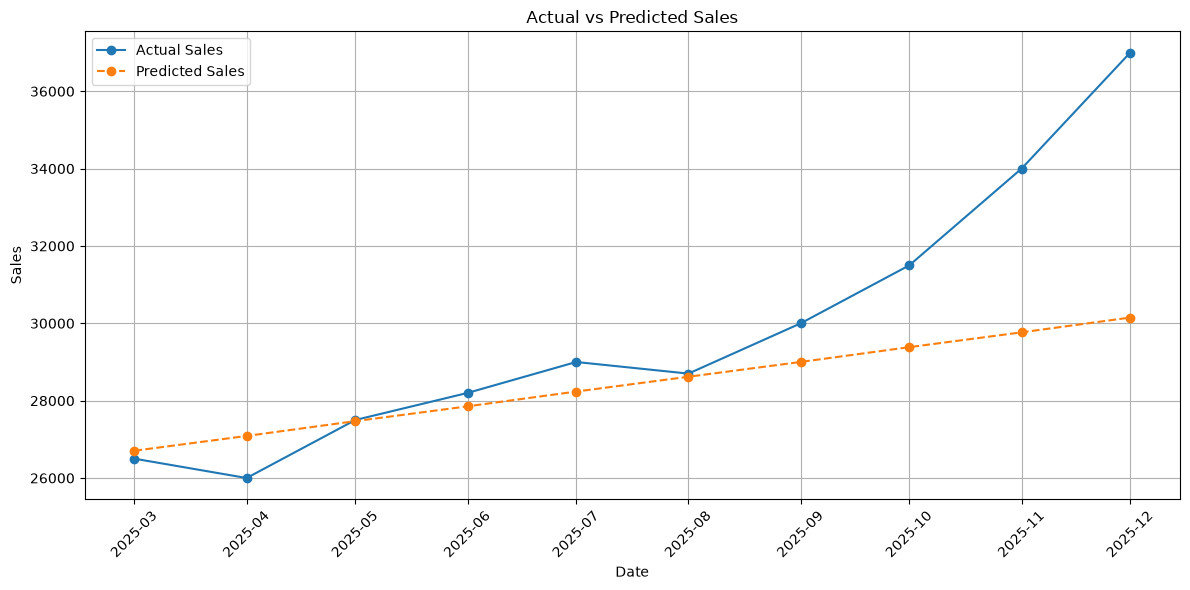

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    prediction_results["Date"],
    prediction_results["Actual Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    prediction_results["Date"],
    prediction_results["Predicted Sales"],
    marker="o",
    linestyle="--",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 16. Forecast Future Sales

The trained Linear Regression model is used to forecast sales for
the next 12 months beyond the historical dataset.

This provides an initial estimate of future sales based on the
historical trend.

In [9]:
last_month = df["Month_Number"].max()

future_months = np.arange(
    last_month + 1,
    last_month + 13
).reshape(-1, 1)

future_predictions = model.predict(future_months)

future_dates = pd.date_range(
    start=df["Date"].max() + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Sales": future_predictions
})

forecast_df

c:\Users\Atharva Joshi\OneDrive\Documents\Predictive-Analytics-Using-Historical-Data\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Date,Forecasted Sales
0,2026-01-01,30531.819674
1,2026-02-01,30914.432651
2,2026-03-01,31297.045629
3,2026-04-01,31679.658606
4,2026-05-01,32062.271583
5,2026-06-01,32444.884561
6,2026-07-01,32827.497538
7,2026-08-01,33210.110515
8,2026-09-01,33592.723493
9,2026-10-01,33975.336470


## 17. Historical Sales and Future Forecast

The historical sales and forecasted values are plotted together
to visualize the expected future sales trend.

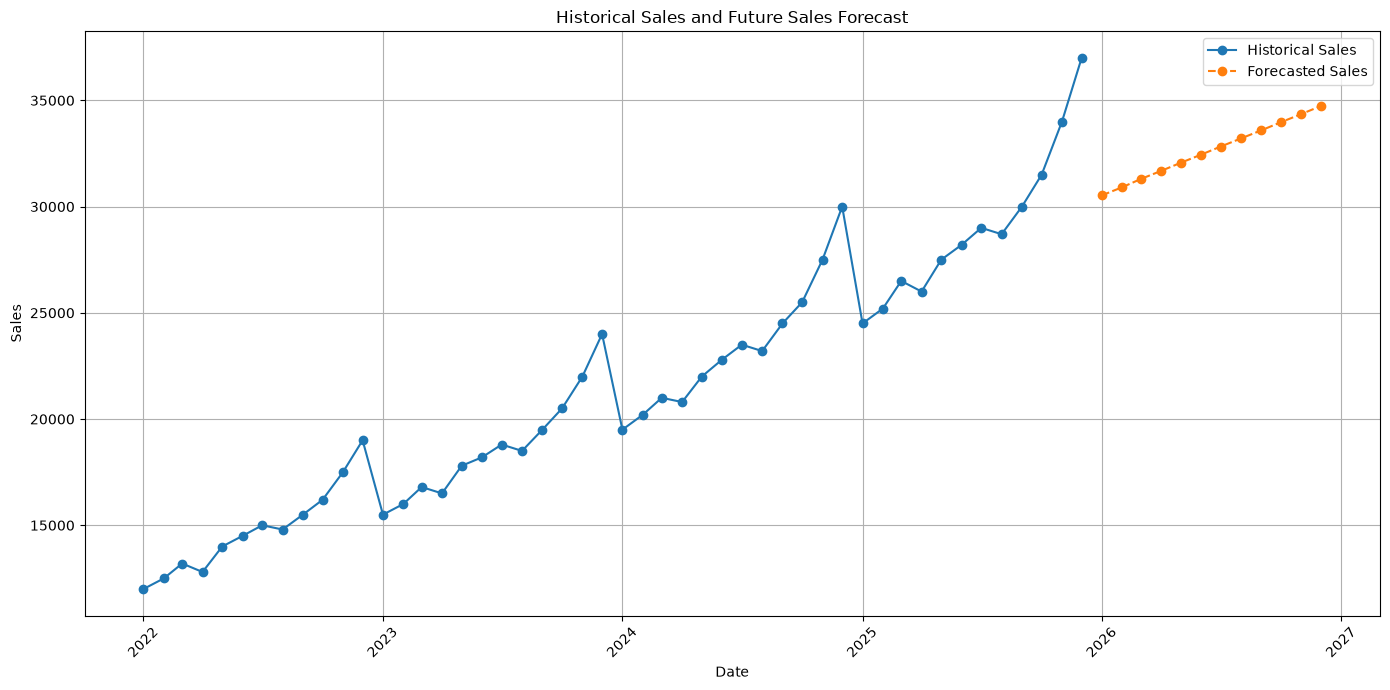

In [10]:
plt.figure(figsize=(14, 7))

plt.plot(
    df["Date"],
    df["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted Sales"],
    marker="o",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Historical Sales and Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 18. Future Sales Forecast

The table below presents the predicted sales values for the next
12 months.

In [11]:
forecast_df

,Date,Forecasted Sales
0,2026-01-01,30531.819674
1,2026-02-01,30914.432651
2,2026-03-01,31297.045629
3,2026-04-01,31679.658606
4,2026-05-01,32062.271583
5,2026-06-01,32444.884561
6,2026-07-01,32827.497538
7,2026-08-01,33210.110515
8,2026-09-01,33592.723493
9,2026-10-01,33975.336470


## 19. Improved Feature Engineering

The baseline Linear Regression model used only the sequential month number
as a feature. To improve the predictive model, additional time-based
features are introduced.

The following features are used:

- Year
- Month
- Month_Number

These features provide the model with additional information about the
historical time pattern.

In [12]:
# Create additional time-based features

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

features = ["Month_Number", "Year", "Month"]

X_improved = df[features]
y_improved = df["Sales"]

X_improved.head()

,Month_Number,Year,Month
0,1,2022,1
1,2,2022,2
2,3,2022,3
3,4,2022,4
4,5,2022,5


## 20. Train-Test Split for the Improved Model

The data is divided chronologically into 80% training data and 20%
testing data.

The chronological split ensures that future observations are not used
to train the model.

In [13]:
split_index = int(len(df) * 0.8)

X_train_improved = X_improved.iloc[:split_index]
X_test_improved = X_improved.iloc[split_index:]

y_train_improved = y_improved.iloc[:split_index]
y_test_improved = y_improved.iloc[split_index:]

print("Training Records:", len(X_train_improved))
print("Testing Records:", len(X_test_improved))

Training Records: 38
Testing Records: 10


## 21. Train the Improved Linear Regression Model

A second Linear Regression model is trained using the additional
time-based features.

This model is compared with the baseline model to determine whether
the additional features improve predictive performance.

In [14]:
improved_model = LinearRegression()

improved_model.fit(X_train_improved, y_train_improved)

print("Improved Linear Regression model trained successfully!")

Improved Linear Regression model trained successfully!


## 22. Generate Improved Model Predictions

The improved model is used to predict sales for the testing period.

In [15]:
y_pred_improved = improved_model.predict(X_test_improved)

improved_predictions = pd.DataFrame({
    "Date": df.loc[X_test_improved.index, "Date"],
    "Actual Sales": y_test_improved.values,
    "Predicted Sales": y_pred_improved
})

improved_predictions

,Date,Actual Sales,Predicted Sales
38,2025-03-01,26500,25388.646617
39,2025-04-01,26000,26060.719656
40,2025-05-01,27500,26732.792696
41,2025-06-01,28200,27404.865736
42,2025-07-01,29000,28076.938776
43,2025-08-01,28700,28749.011815
44,2025-09-01,30000,29421.084855
45,2025-10-01,31500,30093.157895
46,2025-11-01,34000,30765.230934
47,2025-12-01,37000,31437.303974


## 23. Evaluate the Improved Model

The improved model is evaluated using MAE, RMSE, and R² Score.

These results are compared with the baseline Linear Regression model.

In [16]:
mae_improved = mean_absolute_error(
    y_test_improved,
    y_pred_improved
)

rmse_improved = np.sqrt(
    mean_squared_error(
        y_test_improved,
        y_pred_improved
    )
)

r2_improved = r2_score(
    y_test_improved,
    y_pred_improved
)

print(f"Improved MAE: {mae_improved:.2f}")
print(f"Improved RMSE: {rmse_improved:.2f}")
print(f"Improved R² Score: {r2_improved:.4f}")

Improved MAE: 1448.97
Improved RMSE: 2168.77
Improved R² Score: 0.5621


## 24. Model Performance Comparison

The baseline and improved Linear Regression models are compared using
MAE, RMSE, and R² Score.

The model with lower prediction errors and a higher R² Score is considered
the better-performing model.

In [17]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Improved Linear Regression"
    ],
    "MAE": [
        mae,
        mae_improved
    ],
    "RMSE": [
        rmse,
        rmse_improved
    ],
    "R2 Score": [
        r2,
        r2_improved
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Baseline Linear Regression,1671.350257,2688.263031,0.327268
1,Improved Linear Regression,1448.970999,2168.772657,0.562149


## 25. Model Performance Comparison

The following chart compares the R² scores of the baseline and improved
models.

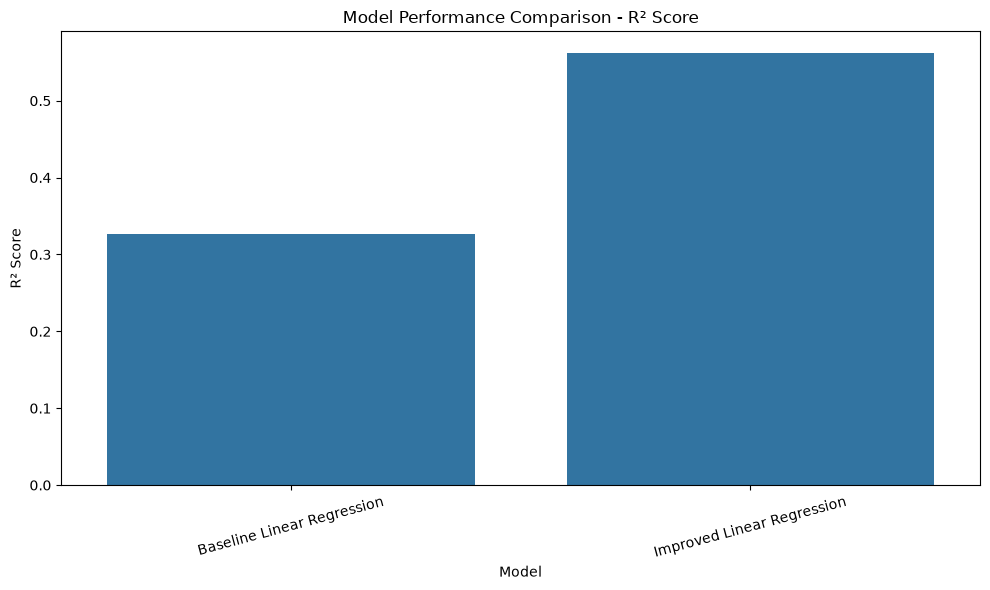

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Model Performance Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


## 26. Actual vs Improved Predicted Sales

The following visualization compares the actual sales values with
the predictions generated by the improved Linear Regression model.

This visualization helps determine how closely the model follows
the actual sales pattern during the testing period.

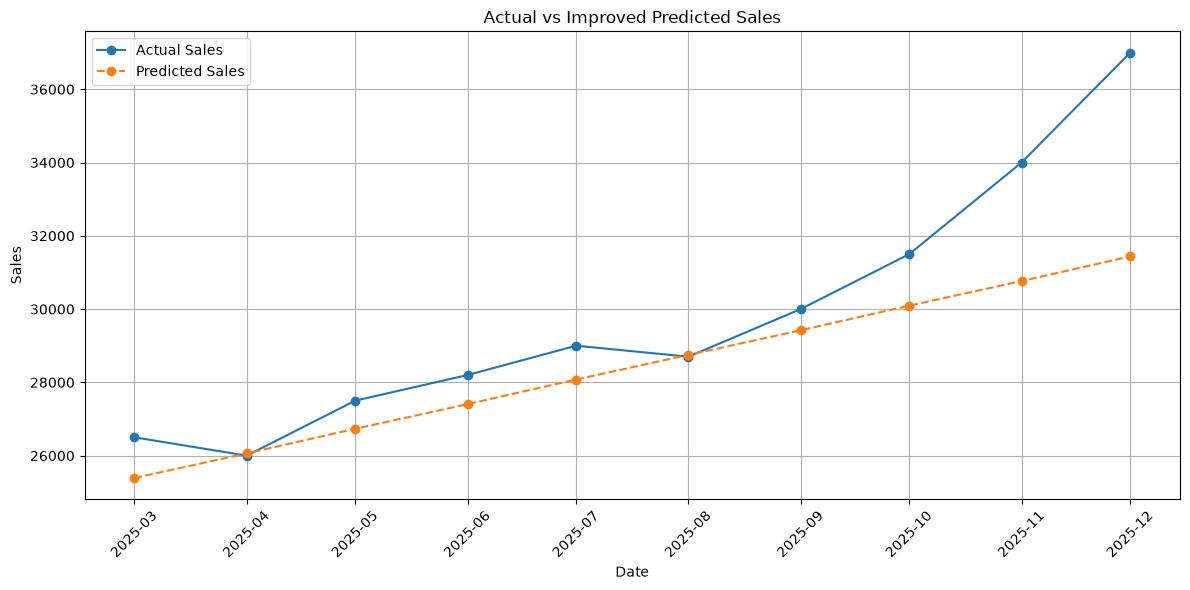

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    improved_predictions["Date"],
    improved_predictions["Actual Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    improved_predictions["Date"],
    improved_predictions["Predicted Sales"],
    marker="o",
    linestyle="--",
    label="Predicted Sales"
)

plt.title("Actual vs Improved Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 27. Prediction Error Analysis

Prediction errors are calculated by comparing the actual sales values
with the predicted values.

Analyzing these errors helps identify where the model performs well
and where larger differences occur.

In [20]:
improved_predictions["Error"] = (
    improved_predictions["Actual Sales"]
    - improved_predictions["Predicted Sales"]
)

improved_predictions

,Date,Actual Sales,Predicted Sales,Error
38,2025-03-01,26500,25388.646617,1111.353383
39,2025-04-01,26000,26060.719656,-60.719656
40,2025-05-01,27500,26732.792696,767.207304
41,2025-06-01,28200,27404.865736,795.134264
42,2025-07-01,29000,28076.938776,923.061224
43,2025-08-01,28700,28749.011815,-49.011815
44,2025-09-01,30000,29421.084855,578.915145
45,2025-10-01,31500,30093.157895,1406.842105
46,2025-11-01,34000,30765.230934,3234.769066
47,2025-12-01,37000,31437.303974,5562.696026


## 28. Prediction Error Over Time

The following chart shows the prediction error for each observation
in the testing period.

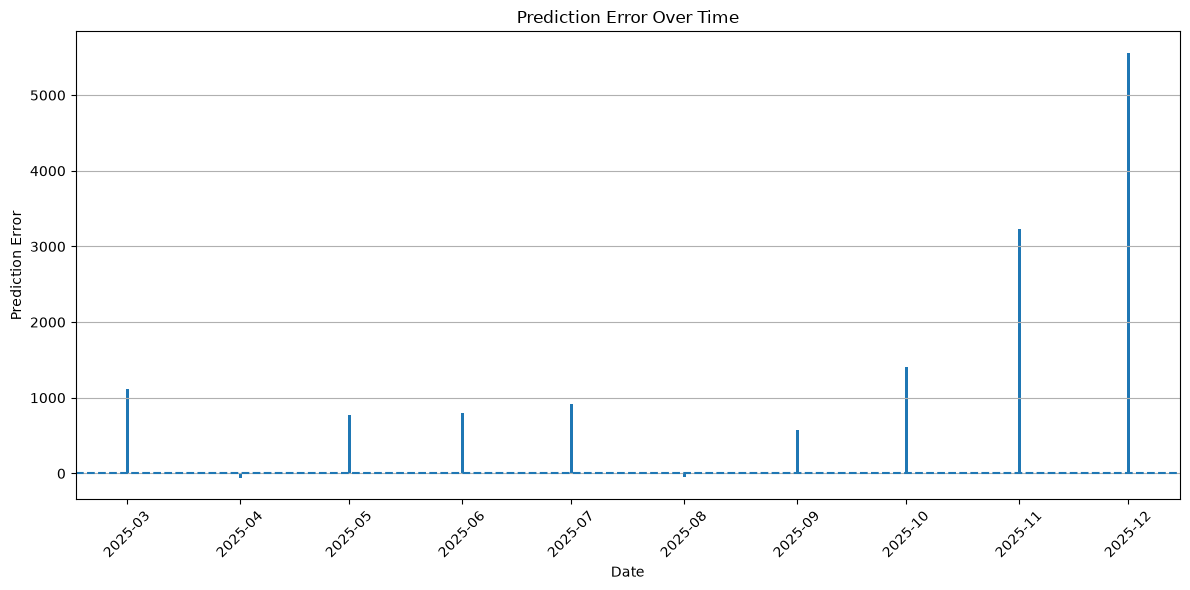

In [21]:
plt.figure(figsize=(12, 6))

plt.bar(
    improved_predictions["Date"],
    improved_predictions["Error"]
)

plt.axhline(0, linestyle="--")

plt.title("Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Prediction Error")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

## 29. Final Model Selection

The improved Linear Regression model performed better than the baseline
model based on all three evaluation metrics.

### Selected Model

**Improved Linear Regression**

### Performance

- MAE: 1448.97
- RMSE: 2168.77
- R² Score: 0.5621

The improved model will therefore be used for the final sales forecast.

## 30. Future Sales Forecast Using the Improved Model

The selected improved Linear Regression model is used to forecast
sales for the next 12 months.

The forecast is based on the historical time-based features used
during model training.

In [22]:
last_month_number = df["Month_Number"].max()
last_date = df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

future_data = pd.DataFrame({
    "Date": future_dates
})

future_data["Month_Number"] = np.arange(
    last_month_number + 1,
    last_month_number + 13
)

future_data["Year"] = future_data["Date"].dt.year
future_data["Month"] = future_data["Date"].dt.month

future_features = future_data[
    ["Month_Number", "Year", "Month"]
]

future_data["Forecasted Sales"] = improved_model.predict(
    future_features
)

future_data

,Date,Month_Number,Year,Month,Forecasted Sales
0,2026-01-01,49,2026,1,28435.244361
1,2026-02-01,50,2026,2,29107.317401
2,2026-03-01,51,2026,3,29779.390440
3,2026-04-01,52,2026,4,30451.463480
4,2026-05-01,53,2026,5,31123.536520
5,2026-06-01,54,2026,6,31795.609560
6,2026-07-01,55,2026,7,32467.682599
7,2026-08-01,56,2026,8,33139.755639
8,2026-09-01,57,2026,9,33811.828679
9,2026-10-01,58,2026,10,34483.901719


## 31. Historical Sales and Future Forecast

The final visualization combines historical sales with the forecasted
sales for the next 12 months.

This provides a clear view of the historical trend and expected
future sales direction.

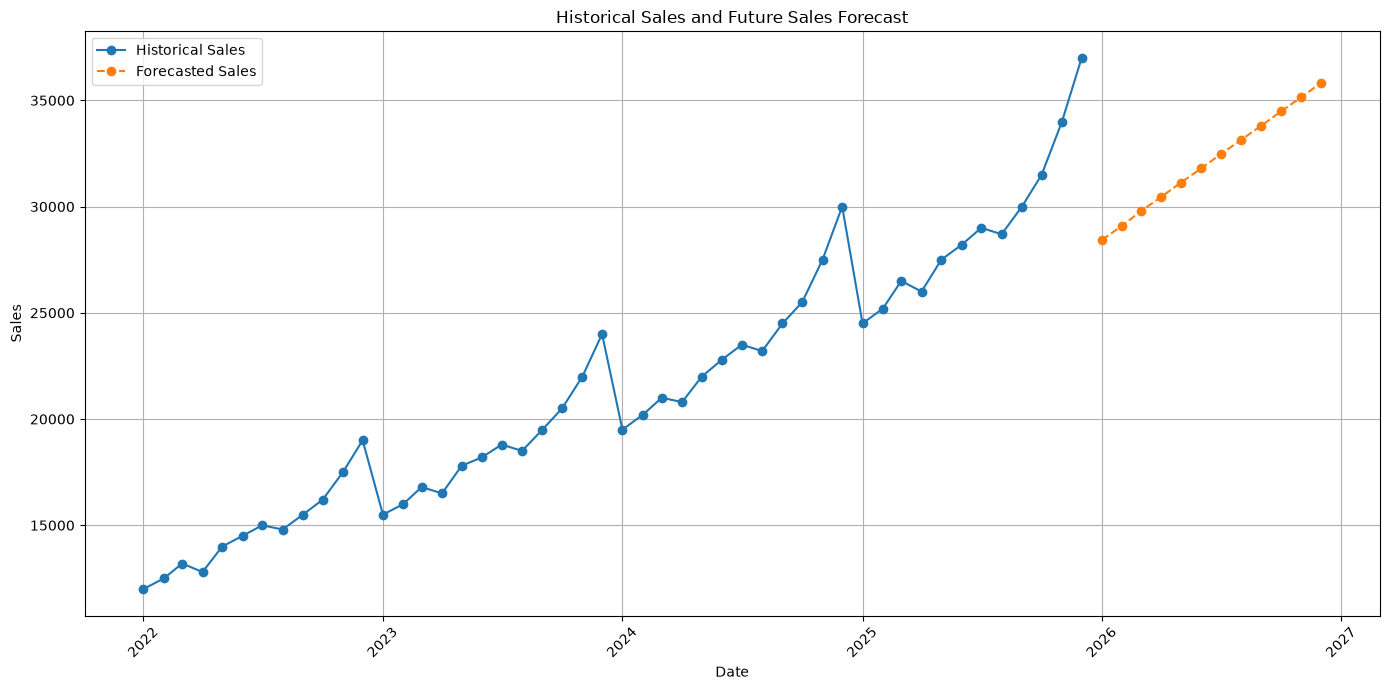

In [23]:
plt.figure(figsize=(14, 7))

plt.plot(
    df["Date"],
    df["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future_data["Date"],
    future_data["Forecasted Sales"],
    marker="o",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Historical Sales and Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 32. Forecast Summary

The final model forecasts sales for the next 12 months based on
historical sales trends and time-based features.

The forecast indicates a continued upward movement in expected sales
during the forecast period.

In [24]:
forecast_summary = future_data[
    ["Date", "Forecasted Sales"]
].copy()

forecast_summary["Forecasted Sales"] = (
    forecast_summary["Forecasted Sales"].round(2)
)

forecast_summary

,Date,Forecasted Sales
0,2026-01-01,28435.24
1,2026-02-01,29107.32
2,2026-03-01,29779.39
3,2026-04-01,30451.46
4,2026-05-01,31123.54
5,2026-06-01,31795.61
6,2026-07-01,32467.68
7,2026-08-01,33139.76
8,2026-09-01,33811.83
9,2026-10-01,34483.90


## 33. Forecast Growth Analysis

The percentage change between the first and last forecasted months
is calculated to understand the expected growth during the forecast
period.

In [25]:
first_forecast = future_data["Forecasted Sales"].iloc[0]
last_forecast = future_data["Forecasted Sales"].iloc[-1]

forecast_growth = (
    (last_forecast - first_forecast) / first_forecast
) * 100

print(f"January 2026 Forecast: {first_forecast:,.2f}")
print(f"December 2026 Forecast: {last_forecast:,.2f}")
print(f"Forecast Growth: {forecast_growth:.2f}%")

January 2026 Forecast: 28,435.24
December 2026 Forecast: 35,828.05
Forecast Growth: 26.00%


## 34. Key Business Insights

Based on the historical analysis and predictive modeling:

1. Historical sales show an overall increasing trend.
2. Sales fluctuate from month to month while maintaining long-term growth.
3. The baseline Linear Regression model achieved an R² Score of 0.3273.
4. Adding time-based features improved the R² Score to 0.5621.
5. The improved model also reduced both MAE and RMSE.
6. The final model predicts continued sales growth during the next
   12 months.
7. Forecasted sales increase from approximately 28,435 in January 2026
   to approximately 35,828 in December 2026.
8. These forecasts can help businesses with sales planning, inventory
   management, resource allocation, and target setting.

## 35. Final Model Performance

The improved Linear Regression model was selected as the final model
because it performed better than the baseline model across the
evaluation metrics.

In [26]:
final_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        mae_improved,
        rmse_improved,
        r2_improved
    ]
})

final_metrics

,Metric,Value
0,MAE,1448.970999
1,RMSE,2168.772657
2,R² Score,0.562149


# 36. Conclusion

This project demonstrated how historical sales data can be used to
perform predictive analytics and future sales forecasting.

The project followed a complete machine learning workflow:

**Data Collection → Data Preprocessing → Exploratory Data Analysis →
Feature Engineering → Model Training → Model Evaluation →
Forecasting → Business Insights**

A baseline Linear Regression model was initially developed.
Additional time-based features were then introduced to improve the
model's predictive performance.

The improved model achieved:

- **MAE:** 1,448.97
- **RMSE:** 2,168.77
- **R² Score:** 0.5621

The final model was used to forecast sales for the next 12 months.
The forecast indicates a continued upward sales trend.

### Future Improvements

The predictive performance could be further improved by incorporating
additional variables such as:

- Product category
- Region
- Marketing expenditure
- Promotions and discounts
- Customer demand
- Seasonal patterns
- Economic factors

Overall, the project demonstrates the use of historical data,
machine learning, visualization, and forecasting to support
data-driven business decisions.